## The Real Projective Line

We explore the rich consequences of a slight change of perspective, where we view matrices as transformations of lines through the origin rather than transformations of points in the plane. We will use stereographic projection to equate the projective line with the unit circle and to equate matrix transformations of the plane with M&ouml;bius transformations of a single real variable. We then classify M&ouml;bius transformations into three types; parabolic, elliptic, and hyperbolic, following the conic section scheme of our previous notebook. We close with an analysis of the fixed points of M&ouml;bius transformations and their role predicting the behavior of iterates of M&ouml;bius transformations.

To begin, we note that every **nonzero** $v\in\maR^2$ has an associated **line**;

\begin{equation*}
  \ell(v) \equiv \{av:a\in\maR\}
\end{equation*}

going through the origin. For example, $\ell([1,2]) = \{[a,2a]:a\in\maR\}$. Now, given an $M\in\maR^{2\times 2}$, we may associate a line with $Mv$ when $Mv\ne 0$. 

\begin{exercise}\label{ex:null0}
Show that $M$ takes a nonzero vector to zero if, and only if, $\det(M)=0$.
\end{exercise}

As a result, given $0\ne v\in\maR^2$ and $M\in\GL_2(\maR)$ (the real 2-by-2 invertible matrices) we see that $M$ takes the line through $v$ to the line through $Mv$. That is,

\begin{equation} \label{eq:projt}
  M\ell(v) = \ell(Mv).
\end{equation}

We illustrate this for our standard elementary transformations; dilation, shear, and rotation, 

\begin{equation}\label{eq:etrans}
  A(\alpha) \equiv \begin{pmatrix} \alpha & 0 \\ 0 & 1/\alpha \end{pmatrix}    \hskip 0.25in
  N(\s) \equiv \begin{pmatrix} 1 & \s \\ 0 & 1 \end{pmatrix}    \hskip 0.25in
  K(\theta) \equiv \begin{pmatrix} \cos(\theta) & -\sin(\theta) \\ \sin(\theta) & \cos(\theta) \end{pmatrix}
\end{equation}

in Figure \ref{fig:2P1}(left). In this sense, $M\in\GL_2(\maR)$ takes lines to lines and therefore can be said to act on the **real projective line**

\begin{equation}\label{eq:PLine}
  \boxed{\maR\maP^1 \equiv \{\ell(v): 0\ne v\in\maR^2\}}
\end{equation}

In order to best work with this set we seek an alternate representation of $\ell(v)$. To that end, with regard to Figure \ref{fig:2P1}(right), we note that every line through the origin, except the one through $[1,0]$, crosses the line 
$\{[t,1]:t\in\maR\}$ at a unique point, and so write

\begin{equation}\label{eq:PLineH}
  \maR\maP^1 = \{[t,1]:t\in\maR\} \cup [1,0].
\end{equation}

We interpret the first piece as simply $\maR$ and the second as "the point at infinity," and so write

\begin{equation}\label{eq:PLineC}
  \boxed{\maR\maP^1 = \maR \cup \infty}
\end{equation}

We note that our use of the definite article in "the point at infinity" was not casual. In particular, as $t$ goes to either $\pm\infty$ in Figure \ref{fig:2P1}(right), the associated line goes to the line through $[1,0]$. This "taming" of $\infty$ by equating it with $[1,0]$ is just a first step - it remains to see how it actually connects to $\maR$ in $\maR\maP^1$ in a way that makes it behave like any other point.

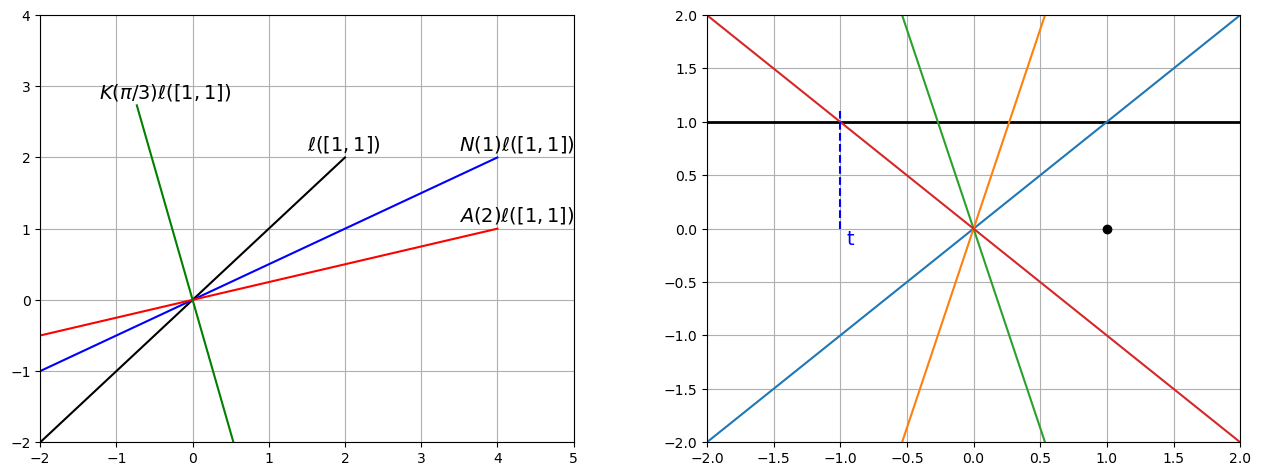

In [1]:
# Transformations of lines, and the projective line 

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2)
plt.subplots_adjust(right=2, top=1, wspace=0.25)

inc = 1/2

x = np.array([2,2])
ax1.plot([-2,2],[-2,2], 'k')
ax1.text(2-inc,2+.1,'$\ell([1,1])$', fontsize=14)

s = 1
N = np.array([[1,s],[0,1]])
y = N@x
ax1.plot([-y[0],y[0]],[-y[1],y[1]],'b')
ax1.text(y[0]-inc, y[1]+.1, '$N(1)\ell([1,1])$', fontsize=14)

a = 2
A = np.array([[a, 0],[0,1/a]])
y = A@x
ax1.plot([-y[0],y[0]],[-y[1],y[1]],'r')
ax1.text(y[0]-inc, y[1]+.1, '$A(2)\ell([1,1])$', fontsize=14)

t = np.pi/3
c = np.cos(t)
s = np.sin(t)
K = np.array([[c, -s],[s,c]])
y = K@x
ax1.plot([-y[0],y[0]],[-y[1],y[1]],'g')
ax1.text(y[0]-inc, y[1]+.1, '$K(\pi/3)\ell([1,1])$', fontsize=14)
ax1.axis([-2,5,-2,4])
#ax1.set_frame_on(False)
ax1.grid('on')

ax2.plot([-2,2],[1,1],'k', linewidth=2)
theta = np.linspace(np.pi/4,3*np.pi/4,4)
for t in theta:
    ax2.plot([-5*np.cos(t), 5*np.cos(t)],[-5*np.sin(t), 5*np.sin(t)])

ax2.plot(1,0,'ko')
ax2.plot([-1,-1],[0, 1.1],'b--')
ax2.text(-.95,-.15,'t', fontsize=14, color = 'b')
ax2.axis([-2,2,-2,2])
ax2.grid('on')

\begin{myfig}\label{fig:2P1} **(left)** A black line through $[1,1]$ and its transformation under dilation, $A(2)$, shear, $N(1)$ and rotation, $K(\pi/3)$. **(right)** An illustration of the projective line (black line and dot) as defined by (\ref{eq:PLineH}). \end{myfig}

### Stereographic Projection

We stitch $\infty$ into $\maR$ in a seamless fashion by mapping the unit circle 

\begin{equation}\label{eq:S1}
  S^1 \equiv \{(Q_x,Q_y)\in\maR^2:Q_x^2+Q_y^2=1\}
\end{equation}

onto $\maR\maP^1$. In particular, denoting the north pole of $S^1$ by $N=[0,1]$
we define **stereographic projection**; $\xi:S^1\setminus N\to\maR$, where $P_x=\xi(Q)$ is the x-intercept of the line through $Q$ and $N$ that is $y=(Q_y-1)x/Q_x+1$ so

\begin{equation}\label{eq:st1}
  P_x = \xi(Q) = \frac{Q_x}{1-Q_y} \and
  Q = \xi^{-1}(P_x) = \frac{(2P_x, P_x^2-1)}{P_x^2+1}
\end{equation}

Please explore this mapping in Figure \ref{fig:st1} below. We now extend $\xi$ to the north pole by simply declaring that $\xi([0,1])=\infty$ and $\xi^{-1}(\infty) = [0,1]$. In this sense, the unit circle, $S^1$, becomes a model for the projective line, $\maR\maP^1$.

In [34]:
# stereographic projection widget

%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import *

plt.ioff()

fig = plt.figure(' ',figsize=(5,5)) 

# plot the unit circle
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), 'b', linewidth=2)
plt.plot([-2,2], [0,0], 'k')
plt.text(2.05, 0, 'x')
plt.plot([0,0], [-2,2], 'k')
plt.text(0, 2.05, 'y')
    
t = 3/4
d = t**2 + 1
x = 2*t/d
y = (t**2-1)/d

plt.plot(0, 1, color = 'b', marker='$N$', markersize=12) 
ray, = plt.plot([0,x,t],[0,y,0],'r',linewidth=2)   # the initial ray
P, =  plt.plot(t, 0, color = 'b', marker='$P$', markersize=12)   
Q, = plt.plot(x, y, color = 'b', marker='$Q$', markersize=12)
plt.axis([-2,2,-2,2])
plt.axis('equal')
plt.grid('on')

xS = widgets.FloatSlider(min=-2, max=2, step=0.1, value=3/4, description='$P_x$') 

def update(t = xS): 
    
    d = t**2 + 1
    x = 2*t/d
    y = (t**2-1)/d
    ray.set_data([0,x,t],[1,y,0])
    P.set_data(t,0)
    Q.set_data(x,y)
    fig.canvas.draw_idle()

widgets.interactive(update)
layoutS = widgets.Layout(display='flex', flex_flow='column', justify_content='center')
controls = widgets.VBox([xS], layout = layoutS)
widgets.HBox([fig.canvas, controls])

\begin{myfig}\label{fig:st1} Stereographic projection of points, $P=(P_x,0)$, onto $Q\in S^1$, via the $\xi^{-1}$ in (\ref{eq:st1}). \end{myfig}

### M&ouml;bius Transformations

We now turn to a more detailed study of the action of $M\in\GL_2(\maR)$ on $\maR\maP^1$. As in our [Matrix Multiplication Notebook](1.3.MatrixMultiplication.ipynb) we restrict attention to those transformations that preserve area and orientation, i.e., to the special linear group $\SL_2(\maR)$ of matrices whose determinant is 1. 

Now for $M\in\SL_2(\maR)$ we note that $-M\in\SL_2(\maR)$ as well and that their actions are indistinguishable on $\maR\maP^1$, i.e., $M\ell(v)=-M\ell(v)$ for each nonzero $v\in\maR^2$. As such, we define the collection of pairs

\begin{equation}\label{eq:psl2}
   \PSL_2(\maR)\equiv\{\{M,-M\}:M\in\SL_2(\maR)\}
\end{equation}

and **define** the product of two pairs, $\{M,-M\}$ and $\{N,-N\}$ as 

\begin{equation}\label{eq:sl2prod}
  \{M,-M\}\{N,-N\}=\{MN,-MN\}.
\end{equation}

\begin{exercise}\label{ex:QG}
Show that $\PSL_2(\maR)$ with the product (\ref{eq:sl2prod}) is a group with identity element $\{I,-I\}$. That is, show (i) that each $A\in\PSL_2(\maR)$ has an inverse in $\PSL_2(\maR)$ and (ii) that for each pair $A$ and $B$ each in $\PSL_2(\maR)$ that $AB\in\PSL_2(\maR)$.
\end{exercise}

We call $\PSL_2(\maR)$ the **projective special linear group** and now embark on a "more concrete" representation. 

With regard to Figure \ref{fig:2P1}(right), for $v=[x,y]$, if $y\ne 0$ then $\ell(v)=\ell([x,y])=\ell([x/y,1])=\ell([t,1])$ where $t=x/y$. Next, with

\begin{equation}
 M = \begin{bmatrix} a & b \\ c & d \end{bmatrix} \in \SL_2(\maR)
\end{equation}

then, thanks to Exercise \ref{ex:null0}, $Mv\ne 0$ and so

\begin{equation}\label{eq:ptrans}
  M(\ell(v)) = \ell(Mv) = \ell(M[x,y]) = \ell(M[t,1]) = \ell([at+b,ct+d]) 
    = \begin{cases} \ell\left(\left[\frac{at+b}{ct+d},1\right]\right) &\hbox{if}\hskip 0.2in ct+d \ne 0, \\
         \ell([1,0]) &\hbox{if}\hskip 0.2in ct+d = 0. \end{cases}
\end{equation}

This $M$ then takes $\ell([1,0])$ to $\ell(M[1,0])=\ell([a,c])$. This is a true line because $a$ and $c$ cannot both vanish.

Hence, each $M\in\SL_2(\maR)$ is associated with the **M&ouml;bius transformation**

\begin{equation}\label{eq:flin}
 \boxed{\mu_M(t) \equiv \frac{at+b}{ct+d}}
\end{equation}

for finite $t$. To see that $\mu_M(t)$ is indeed well defined when $c\ne 0$ and $t=-d/c$ we note that

\begin{equation} \label{eq:flin2}
  \mu_M(-d/c) = \frac{b-ad/c}{0} = \infty \hskip 0.3in \hbox{because}\hskip 0.2in b\ne ad/c
\end{equation}

because $\det(M)=ad-bc=1$ by assumption. In a similar fashion we may evaluate

\begin{equation} \label{eq:flin3}
  \mu_M(\infty) = \frac{a\infty + b}{c\infty + d} = \frac{a + b/\infty}{c + d/\infty} = \frac{a + 0}{c + 0} = a/c
\end{equation}

This last expression, $a/c$, is well defined because $\det(M)\ne 0$ implies that $a$ and $c$ can not both be zero. As such, $\mu_M$ is well defined on the Projective Line $\maR\cup\infty$.

In summary, let us call $\Mob(\maR)$ the collection of functions, $\mu_M$, of the form (\ref{eq:flin}) whose coefficients, $\{a,b,c,d\}$, are drawn from matrices $M\in\SL_2(\maR)$ and write 

\begin{equation}\label{eq:PhiDef}
 \Phi(M) \equiv \mu_M
\end{equation}

for the transformation from $\SL_2(\maR)$ to $\Mob(\maR)$.

\begin{exercise}\label{ex:MobG1} Show that matrix products in $\SL_2(\maR)$ correspond to function compositions in $\Mob(\maR)$. That is 

\begin{equation}\label{eq:pcomp}
    \mu_{MN}(t) = \mu_M(\mu_N(t))
\end{equation}

\end{exercise}

\begin{exercise}\label{ex:MobG2} Show that matrix inversion in $\SL_2(\maR)$ corresponds to function inversion in $\Mob(\maR)$. That is 

\begin{equation}\label{eq:pcomp2}
    \mu_{M^{-1}}(t) = (\mu_M)^{-1}(t)
\end{equation}

\end{exercise}

\begin{exercise}\label{ex:MobG3} Use the previous 2 exercises to deduce that $\Mob(\maR)$ is a group with composition serving as the group product.
\end{exercise}

\begin{exercise}\label{ex:MobPhi} Deduce that the $\Phi$ defined in (\ref{eq:PhiDef}) is a group **homomorphism** in the sense that $\Phi(MN)=\Phi(M)\Phi(N)$.
\end{exercise}

Two homomorphic groups are deemed **isomorphic** when the homomorphism is **one-to-one** and **onto**. Our $\Phi$ is indeed onto, as every $\mu_M\in\Mob(\maR)$ is $\Phi$ of that $M$. As $\Phi(M)=\Phi(-M)$ our $\Phi$ is not one-to-one. As this redundancy is exactly what we vanquished in our construction of $\PSL_2(\maR)$ we expect that it perhaps is isomorphic to $\Mob(\maR)$.

Our proof relies on the general

\begin{proposition}\label{prop:KerId}
If $\phi:G\to H$ is a homomorphism then $\ker(\phi)\equiv\{g\in G:\phi(g)=I\in H\}$ is a subgroup of $G$ and $\phi$ is one-to-one iff  $\ker(\phi)=I\in G$.
\end{proposition}

**Proof:** We first show that $\ker(\phi)$ is a subgroup of $G$. If $g_1$ and $g_2$ lie in $\ker(\phi)$ then $\phi(g_1)=\phi(g_2)=I$ and, as $\phi$ is a homomorphism, $\phi(g_1g_2)=\phi(g_1)\phi(g_2)=II=I$ hence $g_1g_2\in\ker(\phi)$. In addition, as $\phi(I)=\phi(II)=\phi(I)\phi(I)$ we may multiply each side by $\phi(I)^{-1}$ and discover that $\phi(I)=I$. As a result, $I=\phi(I)=\phi(g_1g_1^{-1})=\phi(g_1)\phi(g_1^{-1})=\phi(g_1^{-1})$, i.e., $g_1^{-1}\in\ker(\phi)$.

Next, if $\phi$ is one-to-one then as $\phi(I)=I$ no other $g$ exists for which $\phi(g)=I$ and so $\ker(\phi)=I$. Conversely, if $\phi(g_1)=\phi(g_2)$ then $I=\phi(g_1)\phi(g_2)^{-1}=\phi(g_1g_2^{-1})$, i.e., $g_1g_2^{-1}\in\ker(\phi)$. If $\ker(\phi)=I$ then $g_1g_2^{-1}=I$, i.e, $g_1=g_2$, and so $\phi$ is one-to-one.
**End of proof.**


With this we can finally conclude that our collection of projective transformations, $\PSL_2(\maR)$, is, for all intents and purposes, the collection of M&ouml;bius transformations, $\Mob(\maR)$.

\begin{proposition}\label{prop:MobPG} 
$\PSL_2(\maR)$ is isomorphic to $\Mob(\maR)$.
\end{proposition}

**Proof:** The map $\ov\Phi(\{M,-M\})\equiv \Phi(M)$ takes $\PSL_2(\maR)$ onto $\Mob(\maR)$. We check that

\begin{equation}\label{eq:phibarh}
 \ov\Phi(\{M,-M\}\{N,-N\}) = \ov\Phi(\{MN,-MN\}) = \Phi(MN) = \Phi(M)\Phi(N) = \ov\Phi(\{M,-M\})\ov\Phi(\{N,-N\})
\end{equation}

is a homomorphism. And finally, $\ker(\ov\Phi) = \{\{M,-M\}\in\PSL_2(\maR) : (\Phi(M))(t)=t\} = \{I,-I\}$, the identity element in $\PSL_2(\maR)$.
**End of proof.**

With this we now focus our attention on $\Mob(\maR)$ for the remainder of the notebook.

As we argued in our [Matrix Multiplication Notebook](1.3.MatrixMultiplication.ipynb) that every $M\in\SL_2(\maR)$ can be written as a product of a dilation, shear, and rotatation; $M=A(\alpha)N(\s)K(\theta)$, we expect that something similar must be true of their associated M&ouml;bius transformations;

\begin{equation}\label{eq:Mobsdr}
  \eqalign{
  A_\alpha(t) &= \frac{\alpha t + 0}{0 + 1/\alpha} = \alpha^2 t \cr
  N_\sigma(t) &= \frac{t + \sigma}{0 + 1} = t + \sigma \cr
  K_\theta(t) &= \frac{\cos(\theta) t - \sin(\theta)}{\sin(\theta)t + \cos(\theta)} }
\end{equation}

Regarding their geometric interpretations, the first two are simply multiplication and translation while the latter is a bit harder to see. We note however that it contains

\begin{equation}\label{eq:Kot}
  K_{\pi/2}(t) = -1/t
\end{equation}

and this "rotation" is all that is required to establish

\begin{proposition}\label{prop:MobDecomp} Each M&ouml;bius transformation is a composition of $A_\alpha$, $N_\s$, and $K_{\pi/2}$.

\end{proposition}

**Proof:** If $c=0$ then $a/d>0$ (why?) and so

\begin{equation}\label{eq:Mobd1}
   \frac{at+b}{ct+d} = (a/d)t + (b/d) = N_{b/d}(A_{\sqrt{a/d}}(t)).
\end{equation}

If $c\ne 0$ then

\begin{equation}\label{eq:Mobd2}
   \frac{at+b}{ct+d} = \frac{a}{c} - \frac{1}{c(ct+d)} = N_{a/c}(K_{\pi/2}(N_{cd}(A_c(t))))
\end{equation}

**End of Proof.**

As an aid to visualization we invite the reader to view, in Figure \ref{fig:mu} below, the M&ouml;bius transformation associated with a chosen product of shear, dilation, and rotation.

In [2]:
# fractional linear transformation widget

%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import *

plt.ioff()
t = np.linspace(-10,10,1001)
fig, ax = plt.subplots(constrained_layout=True, figsize=(6, 4), label = ' ')

N = np.array([[1,1],[0,1]])
A = np.array([[1,0],[0, 1]])
K = np.array([[1, 0],[0, 1]])
M = N@A@K
flin, = ax.plot(t,(M[0,0]*t+M[0,1])/(M[1,0]*t+M[1,1]), 'b') #,'.')

ax.plot(t,t,'r')
ax.set_xlabel('t', fontsize=12)
ax.set_ylabel('$\mu_M$', fontsize=12)
ax.axis([-10,10,-10,10])
ax.grid('on')

sigmaS = widgets.FloatSlider(min=-10, max=10, step=0.2, value=1, description='shear: $\sigma$')
alphaS = widgets.FloatSlider(min=0.1, max=10, step=0.1, value=1.5, description='dilation: $\\alpha$') 
thetaS = widgets.FloatSlider(min=0, max=2*np.pi, step=np.pi/50, value=0, description='rotation: $\\theta$')

def update( sigma=sigmaS, alpha=alphaS, theta=thetaS ):
    
    N = np.array([[1,sigma],[0,1]])
    A = np.array([[alpha,0],[0, 1/alpha]])
    K = np.array([[np.cos(theta), -np.sin(theta)],[np.sin(theta), np.cos(theta)]])
    M = N@A@K
    mu = (M[0,0]*t+M[0,1])/(M[1,0]*t+M[1,1])
    ploc = np.where(np.abs(mu)>20)[0]    # pole location
    mu[ploc] = float("nan")              # ignore pole when plotting
    flin.set_data([t,mu])
    fig.canvas.draw()   #_idle()

widgets.interactive(update)
layoutS = widgets.Layout(display='flex', flex_flow='column', justify_content='center')
controls = widgets.VBox([sigmaS, alphaS, thetaS], layout = layoutS)
widgets.HBox([fig.canvas, controls])

\begin{myfig}\label{fig:mu} The blue curve is the graph of $\mu_M(t)$ from (\ref{eq:flin}) where $M=N(\s)A(\alpha)K(\theta)$. It intersects the red diagonal at the fixed points of $\mu_M$. \end{myfig}

As you move the sliders you observe the blue graph meets the red diagonal at 2, 1, or no points in the provided interval. Although we discern from (\ref{eq:Mobsdr}) that $\infty$ is also a fixed point of $A_\alpha$ and $N_\s$ we lack visual confirmation.

To address this lack we move from the "linear" $\maR\cup\infty$ representation of $\maR\maP^1$ to its "circular" representation, $S^1$. In particular, we use the stereographic projection established in (\ref{eq:st1}) to transform $\mu_M(t):\maR\cup\infty\to\maR\cup\infty$ to $\hat\mu_M(Q):S^1\to S^1$ where

\begin{equation}\label{eq:Glift}
    \hat\mu_M(Q) \equiv \xi^{-1}(\mu_M(\xi(Q))).
\end{equation}

Please show that rotations transform nicely under this mapping, namely

\begin{exercise}\label{ex:MobKQ}
Show that $\hat K_\theta(Q) = \xi^{-1}(K_\theta(\xi(Q))) = K(-2\theta)Q$.
\end{exercise}

This is so clean and **easy** to see. In order to see $\hat N_\s$ let us upgrade our stereographic projection widget.
In Figure \ref{fig:hatN} we give the user control over $Q$ and then mark $P\equiv \xi(Q)$ and $P_\s \equiv P + \s$ and $Q_\s \equiv \xi^{-1}(P_\s)=\hat N_\s(Q)$. We see, by construction when $\s>0$, that $P_\s$ lies to the right of $P$ and hence $Q_\s$ is counterclockwise from $Q$.

In [11]:
# stereographic projection upgrade widget

%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import *

plt.ioff()

fig = plt.figure(' ') # ,figsize=(6,6))

# plot the unit circle
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), 'b', linewidth=1)
plt.plot([-2,2], [0,0], 'k')
plt.text(2.05, 0, 'x')
plt.plot([0,0], [-2,2], 'k')
plt.text(0, 2.05, 'y')

s = 1/2
aQ = np.pi/8
Qx = np.cos(aQ)
Qy = np.sin(aQ)
t = Qx/(1-Qy)
d = t**2+1
x = 2*t/d
y = (t**2-1)/d

ts = t + s
ds = ts**2 + 1
xs = 2*ts/ds
ys = (ts**2-1)/ds

plt.plot(0, 1, color = 'b', marker='$N$', markersize=10) 
ray, = plt.plot([0,x,t],[1,y,0],'r',linewidth=1)   # the initial ray
sray, = plt.plot([0,xs,ts],[1,ys,0],'r',linewidth=1)   # the initial ray
P, =  plt.plot(t, 0, color = 'b', marker='$P$', markersize=10)   
Q, = plt.plot(x, y, color = 'b', marker='$Q$', markersize=10)
sP, =  plt.plot(ts, 0, color = 'b', marker='$P_\sigma$', markersize=10)   
sQ, = plt.plot(xs, ys, color = 'b', marker='$Q_\sigma$', markersize=10)
plt.axis([-2,2,-2,2])
plt.axis('equal')
plt.grid('on')

aQW = widgets.FloatSlider(min=0, max=2*np.pi, step=0.1, value=np.pi/8, description='$\\angle Q$') 

def update(aQ = aQW): 
    
    Qx = np.cos(aQ)
    Qy = np.sin(aQ)
    t = Qx/(1-Qy)
    d = t**2+1
    x = 2*t/d
    y = (t**2-1)/d

    ts = t + s
    ds = ts**2 + 1
    xs = 2*ts/ds
    ys = (ts**2-1)/ds
    ray.set_data([0,x,t],[1,y,0])
    P.set_data(t,0)
    Q.set_data(x,y)
    sray.set_data([0,xs,ts],[1,ys,0])
    sP.set_data(ts, 0)   
    sQ.set_data(xs, ys)
    
    fig.canvas.draw_idle()

widgets.interactive(update)
layoutS = widgets.Layout(display='flex', flex_flow='column', justify_content='center')
controls = widgets.VBox([aQW], layout = layoutS)
widgets.HBox([fig.canvas, controls])

\begin{myfig}\label{fig:hatN} Illustration of the fact that $\hat N_\s(Q)$ is counter clockwise rotation of $Q$ when $\s>0$. Please reverse the sign of $\s$ in this code and confirm CW rotation.\end{myfig}

\begin{exercise}\label{ex:hatA}
Please revise this widget to explore the geometry of the conjugated dilation, $\hat A_\alpha(Q)$.
\end{exercise}


The graph of such a function lives on $S^1\times S^1$, which, associating a circle with each point on a circle, we recognize as a torus. More precisely, the domain circle will be the unit circle in the $(x,y)$ plane while, for a given $Q$ on this domain circle, the range circle will be centered at $Q$ and lie in the plane perpendicular to the $(x,y)$ plane. For ease of viewing we will scale every range circle by $1/3$. In order to orient yourself in this new theater please exercise the slider in Figure \ref{fig:tor0} below.

In [12]:
# torus coordinates
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

plt.ioff()

fig = plt.figure(' ')
ax = plt.axes(projection="3d")    # set up for 3D work

# draw the torus
n = 100
theta = np.linspace(0, 2*np.pi, n)
phi = np.linspace(0, 2*np.pi, n)
Theta, Phi = np.meshgrid(theta, phi)
R1, R2 = 1/3, 1   # R1 < R2 creates the whole in the donut
x = (R2 + R1*np.cos(Theta)) * np.cos(Phi)
y = (R2 + R1*np.cos(Theta)) * np.sin(Phi)
z = R1 * np.sin(Theta)
ax.set_zlim(-1,1)
ax.plot_surface(x, y, z, alpha = 0.25, cmap='Spectral')

ax.plot(R2*np.cos(theta), R2*np.sin(theta), np.zeros(n), color='k')

phi = np.pi/4
rcirc, = ax.plot((1 + R1*np.cos(theta))*np.cos(phi), (1 + R1*np.cos(theta))*np.sin(phi), R1*np.sin(theta), color='r')
qdot, = ax.plot(np.cos(phi), np.sin(phi), 0, 'ko')

ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y', fontsize=14)
ax.set_zlabel('z', fontsize=14)

QS = widgets.FloatSlider(min=0, max=2*np.pi, step=0.1, value=np.pi/4, description='$\\angle Q$') 

def update(phi = QS): 
    
    rcirc.set_data_3d((1 + R1*np.cos(theta))*np.cos(phi), (1 + R1*np.cos(theta))*np.sin(phi), R1*np.sin(theta))
    qdot.set_data_3d(np.cos(phi), np.sin(phi), 0)
    fig.canvas.draw_idle()

widgets.interactive(update)
layoutS = widgets.Layout(display='flex', flex_flow='column', justify_content='center')
controls = widgets.VBox([QS], layout = layoutS)
widgets.HBox([fig.canvas, controls])

\begin{myfig}\label{fig:tor0} The torus on which we will draw the graph of $\hat\mu_M$. As the argument $Q$ travels, as a black dot, around the black domain circle the value of $\hat\mu_M(Q)$ will lie on the red range circle. Can you identify the north and south poles of each circle?\end{myfig}

With this orientation we may now proceed to the toroidal version of Figure \ref{fig:mu}.

In [36]:
# graph hat mu_M hat on the torus for a broad class of M

%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

plt.ioff()

fig = plt.figure(' ',figsize=(5,5))
ax = plt.axes(projection="3d")    # set up for 3D work

# draw the torus
n = 100
theta = np.linspace(0, 2*np.pi, n)
phi = np.linspace(0, 2*np.pi, n)
Theta, Phi = np.meshgrid(theta, phi)
R1, R2 = 1/3, 1
x = (R2 + R1*np.cos(Theta)) * np.cos(Phi)
y = (R2 + R1*np.cos(Theta)) * np.sin(Phi)
z = R1 * np.sin(Theta)
ax.set_zlim(-1,1)
ax.plot_surface(x, y, z, alpha = 0.25, cmap='Spectral')
ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y', fontsize=14)
ax.set_zlabel('z', fontsize=14)

# plot the diagonal 
aQ = np.linspace(0, 2*np.pi, 2000)  # Q angles in (x,y) plane
Qx = np.cos(aQ)
Qy = np.sin(aQ)

Dx = (1 + R1*Qx)*Qx
Dy = (1 + R1*Qx)*Qy
Dz = R1*Qy
ax.plot(Dx, Dy, Dz, color='r')

t = Qx/(1-Qy)  # t = xi(Q)

# construct M = NAK
sigma = 0
alpha = 2
theta = 0 #np.pi/2
N = np.array([[1,sigma],[0,1]])
A = np.array([[alpha,0],[0, 1/alpha]])
K = np.array([[np.cos(theta), -np.sin(theta)],[np.sin(theta), np.cos(theta)]])
M = N@A@K

mut = (M[0,0]*t + M[0,1])/(M[1,0]*t + M[1,1])
d = mut**2 + 1
Hmux = 2*mut/d
Hmuy = (mut**2-1)/d
phi = np.arctan2(Hmuy, Hmux)

# plot hat mu
x = (1 + R1*np.cos(aQ))*np.cos(phi)
y = (1 + R1*np.cos(aQ))*np.sin(phi)
z = R1*np.sin(aQ)
rcirc, = ax.plot(x, y, z, color='b')

# find and label crossings, where [x,y,z]=[Dx,Dy,Dz]
loc = np.where((x-Dx)**2 + (y-Dy)**2 + (z-Dz)**2 < 1e-2)[0] 
nloc = np.size(loc)
if nloc > 0:
    loclist = np.array([loc[0]])
    for ind in range(1,nloc):
        if (loc[ind] != loc[ind-1] + 1):  # ignore sequential hits
            loclist = np.append(loclist, loc[ind])
        
    nloclist = np.size(loclist)
 
    if nloclist > 1:  # now check if last is same as first (point at infinity)
        p0 = np.array([x[loclist[0]],y[loclist[0]],z[loclist[0]]])
        pend = np.array([x[loclist[-1]],y[loclist[-1]],z[loclist[-1]]])
        if (np.linalg.norm(p0-pend) < 1):
            nloclist = nloclist - 1

    FP, = ax.plot3D(x[loclist[:nloclist]],y[loclist[:nloclist]],z[loclist[:nloclist]],'k.', markersize=8)

sigmaS = widgets.FloatSlider(min=-10, max=10, step=0.2, value=0, description='shear: $\sigma$') 
alphaS = widgets.FloatSlider(min=0.1, max=10, step=0.1, value=2, description='dilation: $\\alpha$') 
thetaS = widgets.FloatSlider(min=0, max=2*np.pi, step=np.pi/50, value=0, description='rotation: $\\theta$')

def update(sigma = sigmaS, alpha = alphaS, theta = thetaS ):
    
    N = np.array([[1,sigma],[0,1]])
    A = np.array([[alpha,0],[0, 1/alpha]])
    K = np.array([[np.cos(theta), -np.sin(theta)],[np.sin(theta), np.cos(theta)]])
    M = N@A@K
    mut = (M[0,0]*t + M[0,1])/(M[1,0]*t + M[1,1])
    d = mut**2 + 1
    Hmux = 2*mut/d
    Hmuy = (mut**2-1)/d
    phi = np.arctan2(Hmuy, Hmux)
    x = (1 + R1*np.cos(aQ))*np.cos(phi)
    y = (1 + R1*np.cos(aQ))*np.sin(phi)
    z = R1*np.sin(aQ)
    rcirc.set_data_3d(x, y, z)
    
    # find and label crossings, where [x,y,z]=[Dx,Dy,Dz]
    loc = np.where((x-Dx)**2 + (y-Dy)**2 + (z-Dz)**2 < 1e-2)[0] 
    nloc = np.size(loc)
    if nloc > 0:
        loclist = np.array([loc[0]])
        for ind in range(1,nloc):
            if (loc[ind] != loc[ind-1] + 1):  # ignore sequential hits
                loclist = np.append(loclist, loc[ind])
        
        nloclist = np.size(loclist)
 
        if nloclist > 1:  # now check if last is same as first (point at infinity)
            p0 = np.array([x[loclist[0]],y[loclist[0]],z[loclist[0]]])
            pend = np.array([x[loclist[-1]],y[loclist[-1]],z[loclist[-1]]])
            if (np.linalg.norm(p0-pend) < 1):
                nloclist = nloclist - 1

        FP.set_data_3d(x[loclist[:nloclist]],y[loclist[:nloclist]],z[loclist[:nloclist]])
    
    else:
        FP.set_data_3d([np.nan,np.nan,np.nan])
    
    fig.canvas.draw_idle()

widgets.interactive(update)
layoutS = widgets.Layout(display='flex', flex_flow='column', justify_content='center')
controls = widgets.VBox([sigmaS, alphaS, thetaS], layout = layoutS)
widgets.HBox([fig.canvas, controls])

\begin{myfig}\label{fig:mutorus} The blue curve is the graph of $\hat\mu_M(Q)$ from (\ref{eq:Glift}) where $M=N(\s)A(\alpha)K(\theta)$. Each intersection of the blue curve with the red diagonal is a fixed points (black dot) of $\hat\mu_M$.
The widget begins at $M=A(2)$ with fixed points at the north and south poles. Add some shear and observe the motion of the southern point while the north pole remains fixed. Explore pure rotation and observe the disappearance of fixed points. Please tilt and zoom as you explore. \end{myfig}

### Fixed Points

As we graphed M&ouml;bius transformations in the previous section we made sure to flag their fixed points. In this section we will see that the number of fixed points partitions $\Mob(\maR)$ into three classes and that within a class, each M&ouml;bius transformation may be mapped onto a common canonical transformation. Moreover, fixed points also encode the **dynamics** of M&ouml;bius transformations in the sense that values of iterates of a M&ouml;bius transformation are either attracted to or are repelled from its fixed points.

We deem $t*\in\maR\cup\infty$ a **fixed point** of $\mu_M\in\Mob(\maR)$ when $\mu_M(t^*)=t^*$, i.e., when
$(at^*+b)=t^*(ct^*+d)$, i.e., when $t^*$ is a **real** root of the quadratic equation

\begin{equation}\label{eq:muq}
    ct^2 + (d-a)t  - b = 0
\end{equation}

In what follows we will always assume that $M\ne\pm I$ and so $\mu_M(t)$ is not identically $t$.

\begin{exercise}\label{ex:fp1}  Use the quadratic formula and $ad-bc=1$ to show that (\ref{eq:muq}) has

 (a) 2 roots when $|\tr(M)| > 2$, in which case we call $M$ and $\mu_M$ **hyperbolic**

 (b) 1 root when $|\tr(M)| = 2$, in which case we call $M$ and $\mu_M$ **parabolic**, and

 (c) 0 roots when $|\tr(M)| < 2$, in which case we call $M$ and $\mu_M$ **elliptic.**
 
 (d) Show that dilations are hyperbolic and that their fixed points are $0$ and $\infty$, that shears are parabolic with sole fixed point at $\infty$, and that rotations are elliptic.
\end{exercise}

\begin{exercise}\label{ex:fp2}  Show that if $t^*$ is a fixed point of $\mu$ then $Q^*\equiv\xi^{-1}(t^*)$ is a fixed point of $\hat\mu$.
\end{exercise}


We now show that shears and dilations are the **canonical** parabolic and hyperbolic transformations.

Suppose $\mu_M$ is **parabolic** with unique fixed point $t^*$, and note that

\begin{equation}\label{eq:z2i}
  \eta_p(t) = \frac{1}{t^*-t}
\end{equation}

obeys $\eta(t^*)=\infty$ so $\zeta_p(t)\equiv \eta_p(\mu_M(\eta_p^{-1}t))$
has a single fixed point at $\infty$. 

\begin{exercise}\label{ex:scanon} Please confirm that $\zeta_p$ indeed has a single fixed point at $\infty$. Then argue that $\zeta_p$ can only be a shear, i.e., $\zeta_p(t)=t+\s$ for some $\s$.
\end{exercise}

Next, note that if $\mu_M$ is **hyperbolic** with fixed points, $t_1$ and $t_2$, then

\begin{equation}\label{eq:z2iz}
  \eta_h(t) = \frac{t-t_1}{t-t_2}
\end{equation}

maps $t_1$ and $t_2$ to $0$ and $\infty$ respectively. 

\begin{exercise}\label{ex:dcanon} Confirm that $\zeta_h(t)\equiv \eta_h(\mu_M(\eta_h^{-1}t))$  fixes $0$ and $\infty$ and so must be a dilation, i.e., $\zeta_h(t)=\la t$ where $\la\not\in\{0,1\}$.
\end{exercise}

We close this notebook with a consideration of the discreet dynamics of M&ouml;bius transformations. By that we mean the behavior of $\mu_{M^n}(t)$ as $n\to\infty$.

Beginning with dilations we note that

\begin{equation}\label{eq:dildd}
  \mu_{A(\alpha)^n}(t) = \mu_{A(\alpha^n)} = \alpha^{2n}t
\end{equation}

has fixed points at $0$ and $\infty$ and when $\alpha<1$ that $\alpha^{2n}\to 0$ as $n\to\infty$. In this case we say that $0$ is **attracting** and that $\infty$ is **repelling**. Of course these labels get swapped when $\alpha>1$. This behavior is of course easier to visualize, see Figure \ref{fig:DSdyn}(left), in the circle model of $\maR\maP^1$, where $0$ and $\infty$ move to the south and north poles respectively. 

Moving on to shears we note that

\begin{equation}\label{eq:sdd}
  \mu_{N(\s)^n}(t) = \mu_{N(n\s)}(t) = t + n\s
\end{equation}

has a lone fixed point at $\infty$. Recalling Figure \ref{fig:hatN}, we illustrate in Figure \ref{fig:DSdyn}(right) that (when $\s>0$)
$\hat N_{n\s}(Q)$ attracts from the right and repels to the left . 


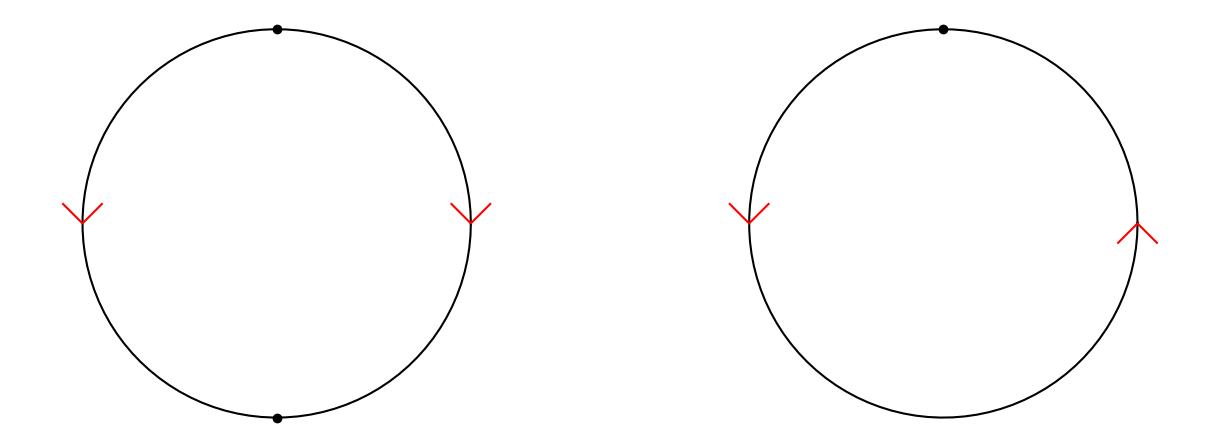

In [7]:
# fixed points of dilations and shears

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

fig, (ax1, ax2) = plt.subplots(1, 2)
plt.subplots_adjust(right=2, top=1, wspace=0.25)

# dilation
theta = np.linspace(0, 2*np.pi, 100)
ax1.plot(np.cos(theta), np.sin(theta), 'k')
ax1.plot(0,1,'ko')
ax1.plot(0,-1,'ko')
ax1.plot([0.9,1,1.1], [0.1, 0, 0.1], 'r')  # arrow heads
ax1.plot([-0.9,-1,-1.1], [0.1, 0, 0.1], 'r') 
ax1.axis('equal')
ax1.axis('off')

# shear
theta = np.linspace(0, 2*np.pi, 100)
ax2.plot(np.cos(theta), np.sin(theta), 'k')
ax2.plot(0,1,'ko')
ax2.plot([0.9,1,1.1], [-0.1, 0, -0.1], 'r')  # arrow heads
ax2.plot([-0.9,-1,-1.1], [0.1, 0, 0.1], 'r') 
ax2.axis('equal')
ax2.axis('off');

\begin{myfig}\label{fig:DSdyn} (left) The dilation $\hat A_{\alpha}$ has fixed points at the north and south poles. When $\alpha<1$ the iterates $\hat A_{\alpha^n}$ move all points (except the north pole) towards the south pole.
(right) The shear $\hat N_\s$ has a lone fixed point at the north pole. When $\s>0$ the iterates $\hat N_{n\s}$ move all points (except the north pole) counter clockwise. \end{myfig}

For our next example we compose a shear and dilation and find

\begin{equation}\label{eq:mu2stab}
  M=N(2)A(3/4) = \begin{bmatrix} 3/4 & 8/3 \\ 0 & 4/3\end{bmatrix}
  \hskip 0.25in \hbox{and its associated} \hskip 0.35in \mu_M(t) = (9/16)t + 2
\end{equation}

As $\tr(M)>2$ we recognize from Exercise \ref{ex:fp1} that $\mu_M$ has two fixed points, one at infinity and the other at
$t^* = 32/7$. The code cell below generates Figure \ref{fig:mu2stab} where we see $\mu_M$, $t^*$, the diagonal, as well as the iterates

\begin{equation}\label{eq:muiter}
  \mu^{(n)}_M(t) \equiv \mu_{M^n}(t), 
\end{equation}

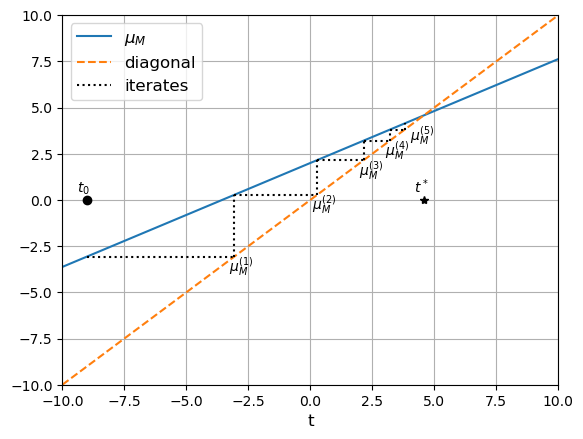

In [8]:
# Mobius Cobwebbing
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(-10,10,101)

sigma = 2
alpha = 3/4
theta = 0
N = np.array([[1,sigma],[0,1]])
A = np.array([[alpha,0],[0, 1/alpha]])
K = np.array([[np.cos(theta), -np.sin(theta)],[np.sin(theta), np.cos(theta)]])
M = N@A@K
plt.plot(t,(M[0,0]*t+M[0,1])/(M[1,0]*t+M[1,1])) #,'.')
plt.plot(t,t,'--')

t = -9
t0 = t

for i in range(1,6):
    v = (M[0,0]*t+M[0,1])/(M[1,0]*t+M[1,1])
    plt.plot([t,v],[v,v],'k:')    # horizontal
    if i<5:
        plt.text(v-.2, v-.8, '$\mu_M^{('+str(i)+')}$', fontsize=10)  # label the iterates
    else:
        plt.text(v+.2, v-.6, '$\mu_M^{(5)}$', fontsize=10)  # different spacing on last label
    t = v
    plt.plot([v,v],[v,(M[0,0]*t+M[0,1])/(M[1,0]*t+M[1,1])], 'k:')  # vertical
    
plt.xlabel('t', fontsize=12)
plt.legend(['$\mu_M$', 'diagonal', 'iterates'], fontsize=12)

tstar = 32/7
plt.plot(tstar,0,'k*')
plt.text(tstar-.4,0.4,'$t^*$')
plt.plot(t0,0,'ko')
plt.text(t0-.4,0.4,'$t_0$')
plt.axis([-10,10,-10,10])
plt.grid('on')

\begin{myfig}\label{fig:mu2stab} Illustration of the $\mu_M$ from (\ref{eq:mu2stab}) and its finite fixed point, $t^*$,
and the iterates, $\mu_M^{(n)}$, as defined by (\ref{eq:muiter}), commencing from $t=t_0$ en route to $t^*$. \end{myfig}

As the iterates, $\mu_n$, in Figure \ref{fig:mu2stab} approach $t^*$ with increasing $n$ we see that $t^*$ **attracting**.  Let us examine the general product of shear and dilation.

\begin{exercise}\label{ex:muNxA} Show that 

\begin{equation}\label{eq:Napow}
  M \equiv N(\s)A(\alpha) = \begin{bmatrix} \alpha & \s/\alpha \\ 0 & 1/\alpha\end{bmatrix} \hskip 0.2in \hbox{and so}\hskip 0.2in 
  \mu_M(t) = \alpha^2 t + \s
\end{equation}

has the finite fixed point

\begin{equation}\label{eq:Nafp}
  t^* = \frac{\s}{1-\alpha^2}.
\end{equation}

Next show that the iterates of $\mu$, as defined in (\ref{eq:muiter}), obey

\begin{equation}\label{eq:Napow2}
  \mu^{(n)}_M(t) = \alpha^{2n} t + \s\sum_{j=0}^{n-1}\alpha^{2j}
\end{equation}

and so conclude that, in the limit as $n\to\infty$,

\begin{equation}\label{eq:Napow3}
  \mu^{(n)}_M(t)  \to \begin{cases} t^* & \hbox{if}\hskip 0.2in \alpha<1, \\ \infty & \hbox{if}\hskip 0.2in \alpha>1.\end{cases}
\end{equation}

In other words, $t^*$ is attracting when $\alpha<1$ and repelling when $\alpha>1$.
\end{exercise}

Careful attention to these examples suggests that the real test for whether or not a fixed point, $t^*$, is attractive is simply whether the slope of $\mu$ is less than one there. Let's first confirm that $\mu_M$ is always increasing.

\begin{exercise}\label{ex:muinv} Show that for each $M\in\SL_2(\maR)$ that

\begin{equation}\label{eq:muprime}
  \frac{d}{dt}\mu_M(t) \equiv \mu_M'(t)=\frac{1}{(ct+d)^2}
\end{equation}

\end{exercise}

We now use Taylor's formula to express

\begin{equation*}
  \eqalign{
  \mu_M(t^*+h) &= \mu_M(t^*) + \mu'_M(t^*)h + O(h^2) = t^* + \mu'_M(t^*)h + O(h^2)\\
  \mu^{(2)}_M(t^*+h) &= \mu_M(\mu_M(t^*+h)) = \mu_M(t^* + \mu'_M(t^*)h + O(h^2)) = \mu_M(t^*) + (\mu'_M(t^*))^2h + O(h^2) }
\end{equation*}

Continuing in this fashion we see that $\mu^{(n)}_M(t^*+h) = t^* + (\mu'_M(t^*))^n h + O(h^2)$ and note that this tends to $t^*$ only when
$|\mu'_M(t^*)|<1$. In light of (\ref{eq:muprime}) we arrive at the explicit

\begin{proposition}\label{prop:StabCrit} **Stability Criterion:** A finite fixed point $t^*$ of $\mu_M$ is attractive when $|ct^*+d|>1$ and repelling when $|ct^*+d|<1$.
\end{proposition}


\begin{exercise}\label{ex:muJac} Show that if $t^*$ is a fixed point of $\mu_M$ then
\begin{equation}\label{eq:stabchk}
 ct^*+d = \frac{\tr(M)\pm\sqrt{\tr^2(M)-4}}{2}
\end{equation}
\end{exercise}

\begin{exercise}\label{ex:fpeig} Fixed points of $\mu_M$ are intimately connected to eigenvalues and eigenvectors of $M$.

(a) Show that $t^*$ is a finite fixed point of $\mu_M$ if, and only if, $[t^*,1]$ is an eigenvector of $M$ with eigenvalue $ct^*+d$, i.e., if and only if

\begin{equation}\label{eq:MeigFP}
  \begin{bmatrix} a & b \\ c & d \end{bmatrix} \begin{bmatrix} t^* \\ 1 \end{bmatrix}
  = (ct^*+d)\begin{bmatrix} t^* \\ 1\end{bmatrix}
\end{equation}


(b) Show that if $\infty$ is a fixed point of $\mu_M$ then $c=0$ and $a$ is an eigenvalue of $M$ with eigenvector $[1,0]$.

(c) Confirm for the $M$ of Exercise \ref{ex:muNxA} that it has eigenvalue $1/\alpha$ and eigenvector $[t^*,1]$ with $t^*$ as in (\ref{eq:Nafp}), and eigenvalue $\alpha$ with eigenvector $[1,0]$.
\end{exercise}

\begin{exercise}\label{ex:NxK}
When $M$ includes rotations we may use the widget above to arrive at $\mu_M$ with two finite fixed points. Show that the fixed points associated with $M=N(2)K(\pi/4)$ are at

\begin{equation}\label{eq:NxK}
  t^*_\pm = 1\pm \sqrt 2
\end{equation}

and determine which is attracting and which is repelling. Check your results by adapting the code that generated Figure \ref{fig:mu2stab} to this $M$.
\end{exercise}

As the $M=N(2)K(\pi/4)$ of the previous exercise is symmetric, i.e., $M[0,1]=M[1,0]$, the eigenvector associated with its largest eigenvalue is revealed by the power method, i.e., by the iterates

\begin{equation}\label{eq:MPow}
  \frac{M^n x}{\|M^n x\|}
\end{equation}

starting from random $x\in\maR^2$, as in Figure \ref{fig:MPow} below. We first introduced the power method in our notebook on Matrix Matrix Multiplication.

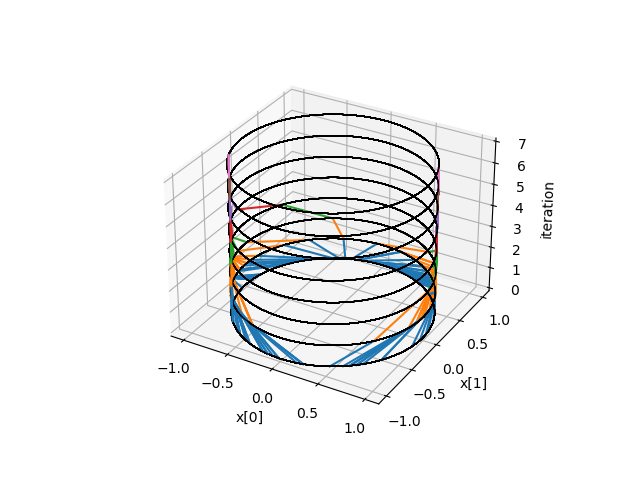

In [42]:
# illustrate the power method (this code was first introduced in our notebook on Matrix Matrix Multiplication)
# for better discrimination plot its orbits on the unit circle by stacking circles by iteration number, n

%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(' ')
ax = plt.axes(projection="3d")    # set up for 3D work

M = np.array([[1,2],[0,1]])@np.array([[1,-1],[1,1]])/np.sqrt(2)  # N(2)K(pi/4)

t = np.linspace(0,2*np.pi,100)  # all angles
z = np.ones(100)

for run in range(100):   # run 100 different orbits
    
    ax.plot3D(np.cos(t), np.sin(t), 0*z, 'k', linewidth=0.75)   # plot unit circle at height 0

    a = t[np.random.randint(0,100)]          # pick a random angle
    x = np.array([np.cos(a), np.sin(a)])     # specify starting vector

    for n in range(1,8):                      # its enough to follow 7 iterates
        y = M@x                               # get new direction
        y = y/np.sqrt(y[0]**2+y[1]**2)        # normalize
        ax.plot3D(np.cos(t), np.sin(t), n*z, 'k', linewidth=0.75)   # plot unit circle at height n
        ax.plot3D([x[0], y[0]],[x[1], y[1]], [n-1,n])  # connect subsequent points in orbit
        x = y                                 # old vec equals new vec
        
    ax.set_prop_cycle(None)    # reset colors

ax.set_xlabel('x[0]');
ax.set_ylabel('x[1]');
ax.set_zlabel('iteration');

\begin{myfig}\label{fig:MPow} One hundred orbits of (\ref{eq:MPow}) when $M=N(2)K(\pi/4)$. \end{myfig}

\begin{exercise}\label{ex:MPow}
Contrast the iterates in Figure \ref{fig:MPow} with those associated with the corresponding M&ouml;bius sequence

\begin{equation}\label{eq:MPowM}
   \frac{1}{\sqrt{1+\mu_{M^n}^2(t)}} \begin{bmatrix} \mu_{M^n}(t) \\ 1 \end{bmatrix}
\end{equation}

starting from random $t\in\maR$. Explain this behavior in terms of the magnitudes of the two eigenvalues of $M$. 

\end{exercise}


<!--

**save this for complex work ??**

In closing, we construct M&ouml;bius Transformations that take three distinct points, $t_1,t_2,t_3$ to the set targets $0,1,\infty$. If each of the $t_k$ is finite then

\begin{equation}\label{eq:Mob3T}
  \mu(t) = \frac{(t-t_1)(t_2-t_3)}{(t_1-t_2)(t_3-t)}
\end{equation}

hits the targets and $ad-bc=(t_2-t_3)(t_1-t_2)(t_3-t_1)\ne 0$. If some $t_j=\infty$ we divide by $t_j$ in (\ref{eq:Mob3T}) and then let $t_j\to\infty$; if $t_1=\infty$ then

\begin{equation}\label{eq:Mob3T1}
  \mu(t) = \frac{(t/t_1-1)(t_2-t_3)}{(1-t_2/t_1)(t_3-t)} \to \frac{-(t_2-t_3)}{(t_3-t)} \hskip 0.25in\hbox{as}\hskip 0.25in t_1\to\infty.
\end{equation}

while if $t_2=\infty$ then

\begin{equation}\label{eq:Mob3T2}
  \mu(t) = \frac{(t-t_1)(1-t_3/t_2)}{(t_1/t_2-1)(t_3-t)} \to \frac{-(t-t_1)}{(t_3-t)} \hskip 0.25in\hbox{as}\hskip 0.25in t_2\to\infty.
\end{equation}

and finally, if $t_3=\infty$ then

\begin{equation}\label{eq:Mob3T3}
  \mu(t) = \frac{(t-t_1)(t_2/t_3-1)}{(t_1-t_2)(1-t/t_3)} \to \frac{-(t-t_1)}{(t_1-t_2)} \hskip 0.25in\hbox{as}\hskip 0.25in t_3\to\infty.
\end{equation}

Moreover, this $\mu$ is unique, for if $\eta$ is a M&ouml;bius Transformation that also sends $\{t_1,t_2,t_3\}$ to $\{0,1,\infty\}$ then $\eta^{-1}\circ\mu$ is a M&ouml;bius Transformation, 

\begin{equation}\label{eq:Mobxi}
  \xi(t) = \frac{at+b}{ct+d}
\end{equation}

with three fixed points $\{0,1,\infty\}$. From $\xi(0)=0$ we glean $b/d=0$ so $b=0$, from $\xi(\infty)=\infty$ that $a/c=\infty$ so $c=0$, and from $\xi(1)=1$ that $a+b=c+d$ so $a=d$ and so $\xi(t)=t$ and so $\eta=\mu$.

\begin{proposition}\label{prop:3Trans} 

If $(t_1,t_2,t_3)$ and $(u_1,u_2,u_3)$ are triples of distinct points in $\maR\maP^1$ then there is a unique M&ouml;bius Transformation $\xi$ such that $\xi(t_k)=u_k$, $k=1,2,3$.
\end{proposition}

**Proof** We use the construction above to build the M&ouml;bius Transformations $\mu$ and $\eta$ where $\mu$ maps $(t_1,t_2,t_3)$ to $(0,1,\infty)$ and $\eta$ maps $(u_1,u_2,u_3)$ to $(0,1,\infty)$. It follows then that $\xi=\eta^{-1}\circ\mu$ maps $(t_1,t_2,t_3)$ to $(u_1,u_2,u_3)$. Its uniqueness also follows as above. **End of Proof**

There is a lovely group of six M&ouml;bius Transformations that permute the elements of the primitive triple $\{0,1,\infty\}$;

\begin{equation}\label{eq:Mob6}
  t,\ 1-t,\ 1/t,\ t/(t-1),\ 1/(1-t),\ (t-1)/t
\end{equation}


\begin{exercise}\label{ex:MobPerm} (a) Please evaluate each of the M&ouml;bius Transformations in (\ref{eq:Mob6}) at the three points $\{0,1,\infty\}$.

(b) Please complete the multiplication table

| $\Delta$ | $t$ | $1-t$ | $1/t$ | $t/(t-1)$ | $1/(1-t)$ | $(t-1)/t$ |
| :-: | :-: | :-: | :-: | :-: | :-: | :-: |
| $t$ | $t$ | $1-t$ | $1/t$ | $t/(t-1)$ | $1/(1-t)$ | $(t-1)/t$ |
| $1-t$ | $1-t$ | $t$ | $(t-1)/t$ | $1/(1-t)$ | $t/(t-1)$ | $1/t$ |
| $1/t$ | $1/t$ | $1/(1-t)$ | || || || ||
| $t/(t-1)$ | $t/(t-1)$ | $(t-1)/t$ | || || || ||
| $1/(1-t)$ | $1/(1-t)$ | $1/t$ | || || || ||
| $(t-1)/t$ | $(t-1)/t$ | $t/(t-1)$ | || || || ||

The entries correspond to the composition of a transformation in the first column with a transformation in the first row, in that order.
For example, $(1-t)\circ(1-t)=1-(1-t)=t$ while $(1-t)\circ(1/t)=1-1/t=(t-1)/t$.

(c) Express the six matrices associated with the transformations in (\ref{eq:Mob6}) and build their associated multiplication table.
\end{exercise}
-->

Next Section: [1.8 The Complex Plane](1.8.ComplexPlane.ipynb)